[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jecampagne/nufftcf/blob/main/notebook/nufftcf_demo_ccf_Emmanoulopoulos.ipynb)

# `nufftcf` Demo: Optical ↔ Gamma Cross-Correlation on a Synthetic *Light Curve* (Emmanoulopoulos)
This notebook illustrates the estimation of a **cross-correlation function (CCF)** between two irregularly sampled time series, in a context close to *reverberation mapping* in high-energy astrophysics (AGN, blazars): we have a light curve (LC) in the **optical** band and an LC in the **gamma** band, potentially offset by a physical delay τ₀. These LCs are sampled with different cadences, observation seasons, gaps, and heteroscedastic measurement noise.

The author thanks Julian Hamo from IJCLab for suggesting this notebook scenario.

## Notebook Pipeline

1. **Simulation of the "true" LC** using [`gammapy_SyLC`](https://github.com/cgalelli/gammapy_SyLC) (This package implements the Timmer & König and Emmanoulopoulos algorithms for light curve simulation): we impose a power-law PSD (`pl`, index `-1.2`) and a log-normal marginal PDF (`lognormal`), over 10 years of daily data.

2. **Construction of two "observational" datasets** from the same underlying LC:
   - An **optical** series, subsampled seasonally with random dropout;
   - A **gamma** series, subsampled similarly but **shifted by a fixed lag `lag_days = 15` days** relative to the optical;
   - Heteroscedastic Gaussian measurement noise (`add_measurement_noise`) is added separately to both series, with different relative noise levels (8% for optical, 15% for gamma).

3. **CCF Calculation** on the lag grid `[-500, 500]` days (1-day step) using three estimators from [`nufftcf`](https://github.com/jecampagne/nufftcf):
   - `compute_ccf_gaussian_nufft` — Gaussian kernel evaluated via the Wiener–Khinchin theorem and NUFFT (FINUFFT);
   - `compute_ccf_rectangle_nufft` — Same approach with a rectangular kernel ("slotting", as in Edelson & Krolik 1988);
   - `compute_ccf_gaussian_realspace` — Direct evaluation (pairwise weighted sum) of the same Gaussian kernel estimator, used here as a validation reference.

4. **Peak location and confidential interval**: use bootstrapping following FR/RSS (Peterson et al. 1998) to get the median location
of the CCF and the 1-sigma CL.

5. **Error Bands via Monte Carlo**: ~100 independent realizations of the gamma series are regenerated (same PSD/PDF parameters, same sampling and noise, but without the injected lag and with different seeds) to estimate the expected dispersion of the CCF under the null hypothesis (no physical correlation), and derive a **peak significance** in terms of σ.



In [1]:
pip -q install   "nufftcf @ git+https://github.com/jecampagne/nufftcf.git"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 44.3 MB/s eta 0:00:00


In [2]:
pip -q install "gammapy_SyLC @ git+https://github.com/cgalelli/gammapy_SyLC.git"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
pip -q install regions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 20.3 MB/s eta 0:00:00


In [4]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.size'         : 13,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 14,
    'xtick.labelsize'   : 14,
    'ytick.labelsize'   : 14,
    'legend.fontsize'   : 12,
    'figure.titlesize'  : 16,
    'figure.titleweight': 'bold',
})

# Build a LC from Emmanoulopoulos_lightcurve_simulator

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from gammapy_SyLC import *

# Define PSD and PDF models
psd_model = pl
pdf_model = lognormal

# Set parameters for the simulation
psd_params = {"index": -1.2}
pdf_params = {"s": 0.5}

In [6]:
import pandas as pd
n_years = 10
index = pd.to_datetime(np.arange(0, n_years * 365, 1), unit="D", origin="2010")
index.name = "Time [Years]"


In [7]:
obs_times = np.linspace(0,len(index),len(index),endpoint=False) * u.d


In [8]:
# Generate synthetic light curve
seed = 21
tseries, times = Emmanoulopoulos_lightcurve_simulator(
    pdf_model, psd_model, obs_times,
    pdf_params=pdf_params, psd_params=psd_params,
    mean=1.0, std=0.5, nsims=1,
    random_state =np.array([seed,], dtype=np.uint64)[0]
)

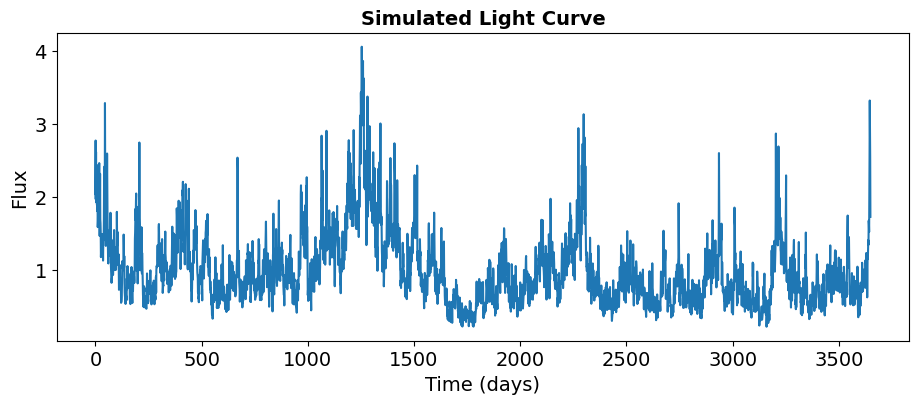

In [9]:
# Plot the simulated light curve
plt.figure(figsize=(11, 4))
plt.plot(times, tseries)
plt.xlabel("Time (days)")
plt.ylabel("Flux")
plt.title("Simulated Light Curve")
plt.show()

# Build Optical & Gamma "experiemntal"  LC

In [10]:
so = pd.Series(data=tseries, index=index, name="Orig.")

In [11]:
def sample_seasonal(
    so: pd.Series,
    season_start_doy: int = 60,
    season_end_doy: int = 300,
    cadence_days: float = 3,
    jitter_days: float = 1,
    dropout_frac: float = 0.15,
    seed: int | None = None,
) -> pd.Series:
    """
    Subsample a time series `so` (DatetimeIndex) by simulating:
      - A single observation season per year (doy between season_start_doy and season_end_doy)
      - An average cadence of `cadence_days` with random jitter
      - Random dropout (e.g., due to weather/scheduling) with fraction `dropout_frac`

    Returns a subsampled series aligned with existing points in `so`
    (no interpolation: the nearest real point is selected).
    """
    rng = np.random.default_rng(seed)
    t0, t1 = so.index[0], so.index[-1]

   # 1) Regular candidate grid
    candidate = pd.date_range(t0, t1, freq=f"{cadence_days}D")

    # 2) Random temporal jitter (+/- jitter_days)
    if jitter_days > 0:
        jitter = rng.uniform(-jitter_days, jitter_days, size=len(candidate))
        candidate = candidate + pd.to_timedelta(jitter, unit="D")
        candidate = candidate[(candidate >= t0) & (candidate <= t1)]

    # 3) Seasonal filter (day of year)
    doy = candidate.dayofyear
    if season_start_doy <= season_end_doy:
        in_season = (doy >= season_start_doy) & (doy <= season_end_doy)
    else:
         # Season spanning the new year
        in_season = (doy >= season_start_doy) | (doy <= season_end_doy)
    candidate = candidate[in_season]

    # 4) Random dropout (weather, scheduling, etc.)
    if dropout_frac > 0:
        keep = rng.random(len(candidate)) > dropout_frac
        candidate = candidate[keep]

    # 5) Match to the nearest real points in `so`
    if len(candidate) == 0:
        return so.iloc[0:0]
    idx_pos = so.index.get_indexer(candidate, method="nearest")
    idx_pos = np.unique(idx_pos)
    return so.iloc[idx_pos].sort_index()


def add_measurement_noise(
    sampled: pd.Series,
    rel_err: float = 0.08,
    abs_err_floor: float = 0.02,
    seed: int | None = None,
) -> pd.DataFrame:
    """
    Add realistic Gaussian measurement noise to a subsampled series
    and return a DataFrame with columns ['flux', 'err'].

    - rel_err: Typical relative uncertainty (fraction of the value)
    - abs_err_floor: Minimum absolute uncertainty (floor, avoids err=0
                     when flux is near 0)
    """
    rng = np.random.default_rng(seed)
    err = np.sqrt((rel_err * sampled.values) ** 2 + abs_err_floor ** 2)
    noisy_flux = sampled.values + rng.normal(0, err)
    return pd.DataFrame({"flux": noisy_flux, "err": err}, index=sampled.index)


def apply_lag(so: pd.Series, lag_days: float = 15) -> pd.Series:
    """
    Time-shift a series: same physical content (same underlying LC),
    but observed with a lead/lag of `lag_days`.

    Useful for simulating a physical lag between two observation bands
    (e.g., gamma/optical delay) while starting from the SAME LC realization.

    lag_days > 0 -> The signal is observed `lag_days` later (the value at time t
                    is shifted to t + lag_days).
    """
    shifted = so.copy()
    shifted.index = so.index + pd.to_timedelta(lag_days, unit="D")
    shifted.name = f"{so.name} (lag={lag_days}d)"
    return shifted

## Optical

In [12]:
def get_optical_serie(so):
    seg1 = sample_seasonal(
            so.iloc[: -7 * 365],
            cadence_days=7, dropout_frac=0.35, seed=1,
        )

    seg2 = sample_seasonal(
            so.iloc[-7 * 365 : -4 * 365],
            cadence_days=3, dropout_frac=0.25, seed=2,
        )

    seg3 = sample_seasonal(
            so.iloc[-4 * 365 :],
            cadence_days=1, dropout_frac=0.15, seed=3,
        )

    s_opt = pd.concat([seg1, seg2, seg3])
    s_opt.name = "Optical (sim, seasonal gaps)"

    return s_opt

In [13]:
s_opt = get_optical_serie(so)
# add some noise
df_opt = add_measurement_noise(s_opt, rel_err=0.08, abs_err_floor=0.03, seed=42)

In [14]:
df_opt

,flux,err
Time [Years],,
2010-03-04,1.345813,0.109204
2010-03-19,0.795069,0.076100
2010-03-26,1.108068,0.088564
2010-04-03,1.075926,0.085130
2010-04-09,0.917081,0.092838
...,...,...
2019-10-21,0.713546,0.058642
2019-10-22,0.736825,0.058595
2019-10-25,0.794671,0.072053


## Gamma

In [15]:
def get_gamma_serie(so):
  gseg1 = sample_seasonal(
          so.iloc[: -7 * 365],
          cadence_days=2, dropout_frac=0.20, seed=11,
      )
  gseg2 = sample_seasonal(
          so.iloc[-7 * 365 : -4 * 365],
          cadence_days=1, dropout_frac=0.15, seed=12,
      )
  gseg3 = sample_seasonal(
          so.iloc[-4 * 365 :],
          cadence_days=0.5, dropout_frac=0.10, seed=13,
      )
  s_gamma = pd.concat([gseg1, gseg2, gseg3])
  s_gamma.name = f"Gamma-ray (sim, lag={lag_days}d, meme saison qu'optique)"

  return s_gamma

In [16]:
# add a lag between the gamma LC and the optical LC
lag_days = 15  # days
so_shifted = apply_lag(so, lag_days=lag_days)
s_gamma = get_gamma_serie(so_shifted)
# add some noise
df_gamma = add_measurement_noise(s_gamma, rel_err=0.15, abs_err_floor=0.05, seed=43)
df_gamma

,flux,err
Time [Years],,
2010-03-03,2.168105,0.317544
2010-03-05,1.665388,0.231698
2010-03-08,1.327796,0.224528
2010-03-12,2.237857,0.392356
2010-03-14,1.207169,0.265015
...,...,...
2019-10-21,0.442931,0.096431
2019-10-23,0.559661,0.106862
2019-10-25,0.435839,0.118604


fig saved in  seasonal_sampling_demo.png


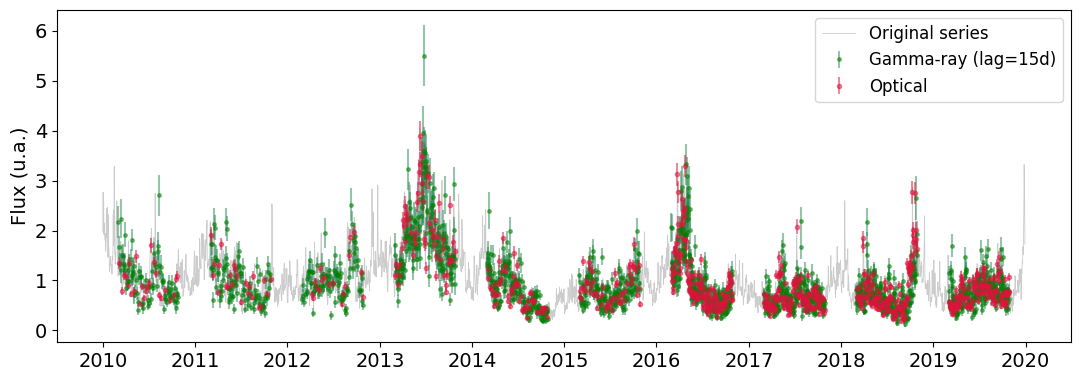

In [17]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(so.index, so.values, color="k", lw=0.6, label="Original series",alpha=0.2)
ax.errorbar(
        df_gamma.index, df_gamma["flux"], yerr=df_gamma["err"],
        fmt="o", ms=2.5, color="green", ecolor="seagreen", alpha=0.5,
        label=f"Gamma-ray (lag={lag_days}d)",
)
ax.errorbar(
        df_opt.index, df_opt["flux"], yerr=df_opt["err"],
        fmt="o", ms=3, color="crimson", ecolor="crimson", alpha=0.5,
        label="Optical",
)
#ax.set_xlabel("Date")
ax.set_ylabel("Flux (u.a.)")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig("seasonal_sampling_demo.png", dpi=150)
print("fig saved in  seasonal_sampling_demo.png")


# Computation of the cross-correlation function with 3 methods
- nufftcf Wiener-Khinchin and gaussian kernel
- nufftcf Wiener-Khinchin and rectangle kernel
- Real space and gaussian kernel

In [18]:
from nufftcf import (
    compute_ccf_gaussian_nufft,
    compute_ccf_rectangle_nufft,
    compute_ccf_gaussian_realspace,
)

One should define a reference date to perform the cross-corr

In [19]:
ref_date = so.index[0]
def t_common(idx, ref_date=ref_date):
    """Number of days (float) elapsed since ref_date, for a DatetimeIndex"""
    return (idx - ref_date) / pd.Timedelta(days=1)


In [20]:
t_num = t_common(df_opt.index)            # time (days) for optical serie
s_num = t_common(df_gamma.index)    # time (days) for gamma serie

x = df_opt["flux"].values         # optical flux
y = df_gamma["flux"].values  #  gamma flux

# --- lags : -500 to +500 days, step  1 day ---
lags = np.arange(-500.0, 501.0, 1.0)

# kernel band width
bin_width = 0.5


In [21]:
c_gn,_ = compute_ccf_gaussian_nufft(lags, t_num, x, s_num, y, bin_width=bin_width)
c_rn,_  = compute_ccf_rectangle_nufft(lags, t_num, x, s_num, y, bin_width=bin_width)
c_gr,_  = compute_ccf_gaussian_realspace(lags, t_num, x, s_num, y, bin_width=bin_width)

Figure saved in : ccf_opt_gamma.png


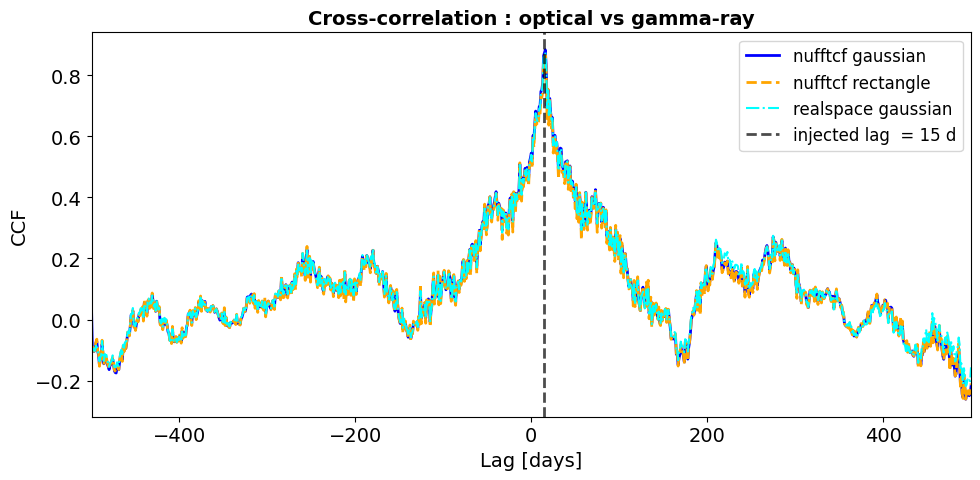

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lags, c_gn, color="blue", lw=2, label="nufftcf gaussian")
ax.plot(lags, c_rn, color="orange", lw=2, ls="--", label="nufftcf rectangle")
ax.plot(lags, c_gr, color="cyan", lw=1.5, ls="-.", label="realspace gaussian")
ax.axvline(lag_days, color="k", lw=2, ls="--", alpha=0.7,
           label=f"injected lag  = {lag_days} d")
ax.set_xlabel("Lag [days]")
ax.set_ylabel("CCF")
ax.set_xlim(lags.min(), lags.max())
ax.legend(loc="upper right")
ax.set_title("Cross-correlation : optical vs gamma-ray")
fig.tight_layout()
fig.savefig("ccf_opt_gamma.png", dpi=150)
print("Figure saved in : ccf_opt_gamma.png")

# Peak location & confidential interval

Use bootstrap Flux Randomization / Random Subset Selection (FR/RSS)
following  [Peterson et al. 1998](https://https://arxiv.org/pdf/astro-ph/9802103)

In [23]:
def peak_lag(lags, ccf, window=None):
    m = np.ones_like(lags, dtype=bool) if window is None \
        else (lags >= window[0]) & (lags <= window[1])
    idx = np.where(m)[0]
    return lags[idx[np.argmax(ccf[idx])]]

def bootstrap_ccpd(df_opt, df_gamma, lags, bin_width,
                    n_boot=500, search_window=(-50, 80), seed0=0):
    rng = np.random.default_rng(seed0)
    t_opt, t_gam = t_common(df_opt.index), t_common(df_gamma.index)
    peaks = np.empty(n_boot)

    for k in range(n_boot):
        # Flux Randomization
        x_b = df_opt["flux"].values + rng.normal(0, df_opt["err"].values)
        y_b = df_gamma["flux"].values + rng.normal(0, df_gamma["err"].values)

        # Random Subset Selection (bootstrap on data points, with duplicates removed)
        i1 = np.unique(rng.integers(0, len(t_opt), len(t_opt)))
        i2 = np.unique(rng.integers(0, len(t_gam), len(t_gam)))

        c_b, _ = compute_ccf_rectangle_nufft(
            lags, t_opt[i1], x_b[i1], t_gam[i2], y_b[i2], bin_width=bin_width
        )
        peaks[k] = peak_lag(lags, c_b, window=search_window)

    return peaks

In [24]:
# with 2000 bootstraps it takes 2min or so on Colab
peak_lags = bootstrap_ccpd(df_opt, df_gamma, lags, bin_width,
                            n_boot=2000, search_window=(-100, 100))

tau_hat = np.median(peak_lags)
lo, hi  = np.percentile(peak_lags, [16, 84])

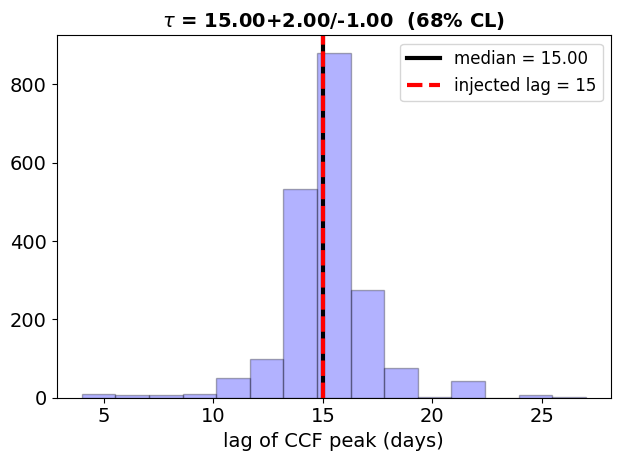

In [25]:
plt.hist(peak_lags, bins=15, color="blue", edgecolor="k", alpha=0.3)
plt.axvline(tau_hat, color="k", ls="-",lw=3, label=f"median = {tau_hat:.2f}")
plt.axvline(lag_days, color="r", ls="--", lw=3, label=f"injected lag = {lag_days}")
plt.xlabel("lag of CCF peak (days)")
plt.title(fr"$\tau$ = {tau_hat:.2f}+{hi-tau_hat:.2f}/-{tau_hat-lo:.2f}  (68% CL)")
plt.legend()
plt.tight_layout()
plt.show()

# Error bands analysis

Keep 'optical' serie, and
generate 100 new series of "gamma" LC with same simulator parameters, ans same sampling as previous gamma LC but no time shift and different seeds.

In [26]:
def generate_gamma_s(seed):
    tseries, times = Emmanoulopoulos_lightcurve_simulator(
      pdf_model, psd_model, obs_times,
      pdf_params=pdf_params, psd_params=psd_params,
      mean=1.0, std=0.5, nsims=1,
      random_state =np.array([seed,], dtype=np.uint64)[0])

    so_n = pd.Series(data=tseries, index=index, name="new orig.")
    s_gamma_n = get_gamma_serie(so_n)
    df_gamma_n = add_measurement_noise(s_gamma_n, rel_err=0.15, abs_err_floor=0.05, seed=seed)

    return df_gamma_n

In [27]:
def compute_ccf_opt_gam(n_series=10, init_seed=100):
    seeds = np.arange(init_seed, init_seed + n_series, 1)
    t_num = t_common(df_opt.index)
    x = df_opt["flux"].values

    # --- one single batched call to simulation
    master_seed = np.array([init_seed], dtype=np.uint64)[0]
    tseries_all, times = Emmanoulopoulos_lightcurve_simulator(
        pdf_model, psd_model, obs_times,
        pdf_params=pdf_params, psd_params=psd_params,
        mean=1.0, std=0.5, nsims=n_series,
        random_state=master_seed,
    )
    # tseries_all.shape == (n_series, npoints)

    c_rn_all = []
    for tseries, seed in zip(tseries_all, seeds):
        so_n = pd.Series(data=tseries, index=index, name="new orig.")
        s_gamma_n = get_gamma_serie(so_n)
        df_gamma_n = add_measurement_noise(s_gamma_n, rel_err=0.15, abs_err_floor=0.05, seed=seed)

        s_num = t_common(df_gamma_n.index)
        y = df_gamma_n["flux"].values

        c_rn, _ = compute_ccf_rectangle_nufft(lags, t_num, x, s_num, y, bin_width=bin_width)
        c_rn_all.append(c_rn)

    return c_rn_all

## generation of random realizations

In [29]:
c_rn_all = compute_ccf_opt_gam(n_series=100) # t takes 1min or so on Colab

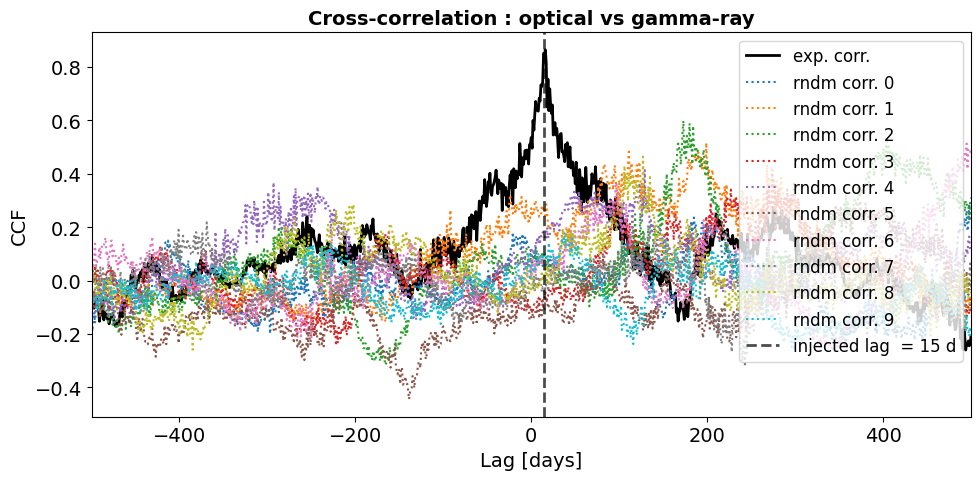

In [30]:
# plot 10-realisations
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lags, c_rn, color="k", lw=2, ls="-", label="exp. corr.")

for i in range(10):
  ax.plot(lags, c_rn_all[i], lw=1.5, ls=":", label=f"rndm corr. {i}")

ax.axvline(lag_days, color="k", lw=2, ls="--", alpha=0.7,
            label=f"injected lag  = {lag_days} d")
ax.set_xlabel("Lag [days]")
ax.set_ylabel("CCF")
ax.set_xlim(lags.min(), lags.max())
ax.legend(loc="upper right")
ax.set_title("Cross-correlation : optical vs gamma-ray")
fig.tight_layout()
fig.savefig("ccf_opt_gamma_10rndm.png", dpi=150)

In [31]:
tmp = np.array(c_rn_all)
np.save("ccf_rndm_all.npy",tmp)
np.save("ccf_good.npy",c_rn)

In [32]:
# mean and std of the set of series CCF
mean_c_rn = np.mean(tmp,axis=0)
std_c_rn      = np.std(tmp,axis=0)

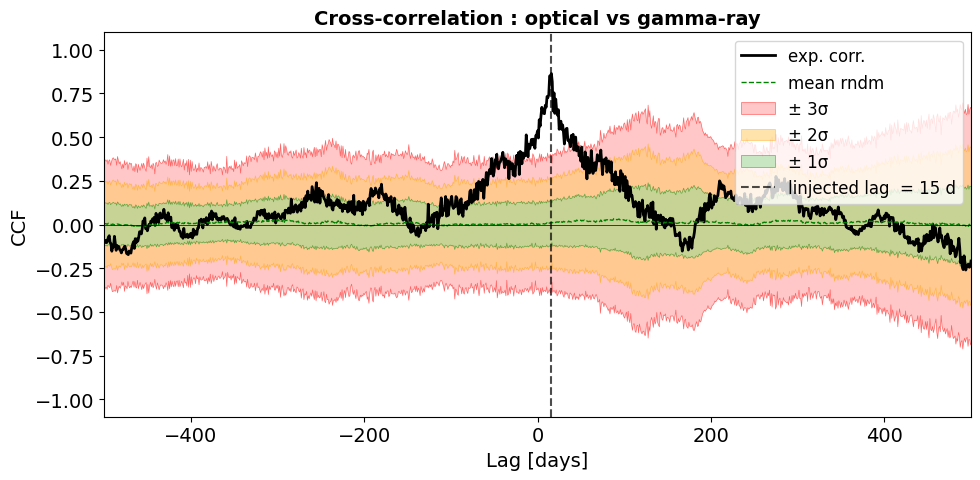

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lags, c_rn, color="k", lw=2, ls="-", label="exp. corr.")
ax.plot(lags, mean_c_rn, color="green", lw=1, ls="--", label="mean rndm")

colors     = ["#FF9999", "#FFCC66", "#99DD99"]
edgecolors = ["red","orange","green"]
for idx,n in enumerate([3, 2,1]):
    lower = mean_c_rn - n * std_c_rn
    upper = mean_c_rn + n * std_c_rn
    ax.fill_between(
        lags,
        lower,
        upper,
        alpha=0.55,
        color=colors[idx % len(colors)],
        edgecolor=edgecolors[idx % len(edgecolors)],
        lw=0.5,
        label=f"± {n}σ",
    )

ax.axvline(lag_days, color="k", lw=1.5, ls="--", alpha=0.7,
            label=f"linjected lag  = {lag_days} d")
ax.axhline(0, xmin=lags.min(),xmax= lags.max(),color="k",lw=0.5,ls='-')
ax.set_xlabel("Lag [days]")
ax.set_ylabel("CCF")
ax.set_xlim(lags.min(), lags.max())
ax.legend(loc="upper right")
ax.set_title("Cross-correlation : optical vs gamma-ray")
ax.set_ylim([-1.1,1.1])
fig.tight_layout()
fig.savefig("ccf_opt_gamma_with_band.png", dpi=150)

## number of sigmas of the peak

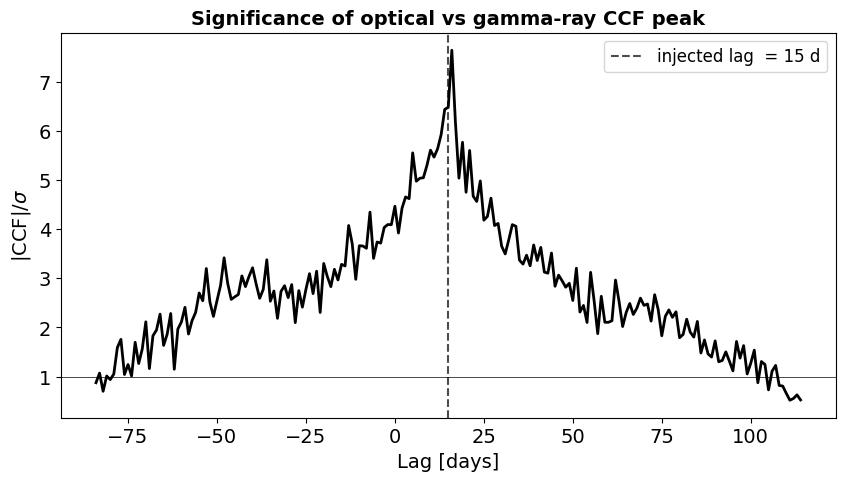

In [34]:
mask =np.abs(lags-lag_days)<100
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title("Significance of optical vs gamma-ray CCF peak")
ax.plot(lags[mask], np.abs(c_rn[mask])/(std_c_rn[mask]), color="k", lw=2, ls="-")
ax.set_xlabel("Lag [days]")
ax.set_ylabel(fr"|CCF|/$\sigma$");
ax.axhline(1, xmin=lags.min(),xmax= lags.max(),color="k",lw=0.5,ls='-')
ax.axvline(lag_days, color="k", lw=1.5, ls="--", alpha=0.7,
            label=f"injected lag  = {lag_days} d")
ax.legend(loc="upper right")

fig.savefig("ccf_peak_significance.png", dpi=150)

## Why Is the CCF Peak Below 1?

The cross-correlation peak is indeed recovered at the injected lag (`lag_days = 15` days). However, the **amplitude remains significantly below 1**, whereas in an ideal case (where the two series differ only by a simple time shift, with no other alterations), we would expect `CCF(τ₀) = ACF(0) = 1`.

The primary reason here is the **independent measurement noise added to each band** via `add_measurement_noise` (in the *Optical* and *Gamma* sections): each simulated flux point is perturbed by heteroscedastic Gaussian noise, with different relative levels for the optical (`rel_err=0.08`) and gamma (`rel_err=0.15`) bands, and independent random seeds.

Formally, if `Y(t) = X(t-τ₀) + N(t)` where `N` is noise independent of `X`, the cross-correlation at the peak is:

$$
\rho = \frac{\sigma_X}{\sqrt{\sigma_X^2 + \sigma_N^2}} < 1
$$

Since both bands receive their **own independent noise realizations** (and at different levels), this noise is by design never correlated between the optical and gamma bands: it only inflates the variance of each series without ever contributing to the numerator of the correlation, which mechanically pulls the peak below 1.

Other, more secondary effects here also contribute to this:
- The irregular and differing sampling between the two bands (different cadences, seasons, and *dropout* rates) reduces the effective overlap of available pairs around the lag.
- The finite width of the kernel (`bin_width = 0.5` days) slightly smooths the peak.
- Edge effects due to the finite length of the series.